Content of this notebook:
- open trials_df
- take the list of images in trials_df['image_path'] and the corresponding labels in traials_df['label'] column
- classify them with a custom CNN and a pre-trained ResNet model, with train/val
- test the two models
- use the best model to extract the features of the images and save them in image_features.npz

In [1]:
from utils import variables, functions

# realod them (maybe have been updated)
import importlib
importlib.reload(functions)
importlib.reload(variables)

import numpy as np, os, json, pandas as pd, random, pickle, math
from IPython.display import clear_output
from PIL import Image

# Matplotlib
import matplotlib.pyplot as plt

# Torch
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import itertools
import torch.optim as optim

Variables imported correctly.
Functions imported correctly.
Functions imported correctly.
Variables imported correctly.


In [2]:
# Load all the dataframes
functionals_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv'))
events_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'events_df.csv'))
trials_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'trials_df.csv'))

To do:
- open trials_df
- take the list of images in trials_df['image_path']
- open each image and extract the features with Res Net 50
- save the data 

In [3]:
trials_df.head(3)

,events_path,image_name,label,dataset,image_path
0,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n01930112_19568.JPEG,animal or human,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...
1,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n03733281_29214.JPEG,object,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...
2,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n07695742_5848.JPEG,plant or food,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...


In [4]:
# Check that there are no COCO images in trials_df
# And create the path of each image, and take paths and labels
image_paths = []
labels = []

for row in range(len(trials_df)):
    assert trials_df['dataset'][row].lower() != 'coco'

    dataset_type = trials_df['dataset'][row]
    if 'imagenet' in dataset_type:
        dataset = 'ImageNet'
    elif 'scene' in dataset_type:
        dataset = 'Scene'
    else:
        print(f'Error at row {row}')

    image_name = trials_df['image_name'][row]
    image_path = os.path.join(
        variables.BOLD5000_PATH,
        'Scene_Stimuli', 'Presented_Stimuli',
        dataset, image_name
    )

    image_paths.append(image_path)
    labels.append(trials_df['label'][row])

In [5]:
# Dataset class
class BOLD5000Dataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [6]:
# From strings to integers
le = LabelEncoder() 
labels = le.fit_transform(labels)

# Trainval/test split
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f'Len train+val: {len(trainval_paths)}')
print(f'Len test: {len(test_paths)}')
print(f'Number of classes: {len(set(trainval_labels))}')

Len train+val: 8954
Len test: 2239
Number of classes: 4


In [7]:
# Images transforms (standard ImageNet statistis)
transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   
        std=[0.229, 0.224, 0.225]
    )
])

transform_cnn = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   
        std=[0.229, 0.224, 0.225]
    )
])

##### Custom CNN for classification 

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, num_filters=32):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, num_filters, kernel_size=3, padding=1) 
        self.bn1 = nn.BatchNorm2d(num_filters) 
        self.conv2 = nn.Conv2d(num_filters, num_filters*2, kernel_size=3, padding=1) 
        self.bn2 = nn.BatchNorm2d(num_filters*2) 
        self.pool = nn.MaxPool2d(2, 2)

        self.adapt = nn.AdaptiveAvgPool2d((4, 4))

        # Fully connected 
        self.fc1 = nn.Linear((num_filters*2) * 4 * 4, 32) 
        self.fc2 = nn.Linear(32, num_classes)

        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # 32 → 16 
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # 16 → 8 
        x = self.adapt(x) # → (4×4) 
        x = x.view(x.size(0), -1) 
        x = F.relu(self.fc1(x)) 
        x = self.dropout(x)
        
        return self.fc2(x)

    def extract_features(self, x): 
        '''
        Return feature vector of dimension 32.
        '''
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) 
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) 
        x = self.adapt(x) 
        x = x.view(x.size(0), -1) 
        x= F.relu(self.fc1(x)) 
        
        return x # shape: (batch, 32)

In [11]:
try:
    from torchinfo import summary
except:
    !pip install torchinfo
    from torchinfo import summary
clear_output()

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleCNN(num_classes=4).to(device)
summary(model, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 4]                    --
├─Conv2d: 1-1                            [1, 32, 64, 64]           896
├─BatchNorm2d: 1-2                       [1, 32, 64, 64]           64
├─MaxPool2d: 1-3                         [1, 32, 32, 32]           --
├─Conv2d: 1-4                            [1, 64, 32, 32]           18,496
├─BatchNorm2d: 1-5                       [1, 64, 32, 32]           128
├─MaxPool2d: 1-6                         [1, 64, 16, 16]           --
├─AdaptiveAvgPool2d: 1-7                 [1, 64, 4, 4]             --
├─Linear: 1-8                            [1, 32]                   32,800
├─Dropout: 1-9                           [1, 32]                   --
├─Linear: 1-10                           [1, 4]                    132
Total params: 52,516
Trainable params: 52,516
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 22.64
Input size (MB): 0.05
Forward/bac

Grid Search

In [13]:
grid_params = {
        "lr": [0.01, 0.001],
        "optimizer": ["adam", "sgd"],
        "num_filters": [16, 32],
        "batch_size": [32, 64]
}

In [14]:
def train_grid_search_cnn(grid_params, num_epochs, trainval_paths, trainval_labels, num_classes, device="cuda"):

    # Since the class are unbalanced I will chose the best model as the one with the highest F1 score (macro)
    best_params = None
    best_val_f1 = 0
    best_val_acc = 0

    # Train / val split
    train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=0.2, random_state=41, stratify=trainval_labels
    )

    # Compute class weights from training labels only
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum()  # normalize

    class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
    print("Class weights:", class_weights)

    train_dataset = BOLD5000Dataset(train_paths, train_labels, transform = transform_cnn)
    val_dataset = BOLD5000Dataset(val_paths, val_labels, transform = transform_cnn)

    param_grid = list(ParameterGrid(grid_params))
    
    for i, params in enumerate(param_grid):

        print(f'Combination {i+1}/{len(ParameterGrid(grid_params))} - Params: {params}')

        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

        # pin_memory = True alloca i batch in una zona speciale della RAM chiamata pinned memory.
        # Permette trasferimenti più veloci tra CPU e GPU, i batch arrivano alla GPU piu rapidamente
        # num_workers? quando si usa dataloader, pytorch deve leggere immagini, applicare transform e preparar ei batch
        # se num_workers=0 questi lavori li fa il processo principale, che è lo stesso che allena la rete
        # se num_workers>0: pytorch crea piu processi paralleli che preparano i batch in anticipo

        model = SimpleCNN(num_classes=num_classes, num_filters=params['num_filters']).to(device)
        
        # Criterion, optimizer and scheduler
        criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))

        if params['optimizer'] == "adam":
            optimizer = optim.Adam(model.parameters(), lr=params['lr'])
        elif params['optimizer'] == "sgd":
            optimizer = optim.SGD(model.parameters(), lr=params['lr'], momentum=0.9)
        
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        # Train 
        for epoch in range(num_epochs):

            model.train() 
            train_preds, train_true = [], []
            train_loss = 0.0
            
            for imgs, labels in train_loader: 
                imgs, labels = imgs.to(device), labels.to(device) 
                optimizer.zero_grad() 
                outputs = model(imgs) 
                loss = criterion(outputs, labels) 
                loss.backward() 
                optimizer.step()

                train_loss += loss.item()
                pred = outputs.argmax(dim=1).cpu().numpy()
                train_preds.extend(pred)
                train_true.extend(labels.cpu().numpy())

            train_loss /= len(train_loader)
            train_acc = accuracy_score(train_true, train_preds)
            train_f1 = f1_score(train_true, train_preds, average="macro", zero_division=0)


            # Validation
            model.eval()
            val_loss = 0.0
            val_preds, val_true = [], []
            with torch.no_grad():
                for imgs, labels in val_loader: 
                    imgs, labels = imgs.to(device), labels.to(device) 
                    
                    outputs = model(imgs) 
                    loss = criterion(outputs, labels) 
            
                    val_loss += loss.item() 
                    val_preds.extend(outputs.argmax(dim=1).cpu().numpy()) 
                    val_true.extend(labels.cpu().numpy())
            
            val_loss /= len(val_loader)

            val_acc = accuracy_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)

            # Scheduler step
            scheduler.step(val_loss)

            # Save the best one
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_params = params
                best_val_acc = val_acc
  
            # Print metrics
            print(f"Epoch {epoch:3d}/{num_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        
        del model 
        del optimizer 
        del scheduler 
        torch.cuda.empty_cache()

        print('\n')

    return best_params, best_val_f1, best_val_acc 

In [15]:
print(f'Number of combinations: {len(ParameterGrid(grid_params))}\n')

device = "cuda" if torch.cuda.is_available() else "cpu"
if not os.path.exists(os.path.join(variables.BOLD5000_PATH, 'best_params_cnn.txt')):
    best_params, best_val_f1, best_val_acc = train_grid_search_cnn(grid_params, num_classes=4, num_epochs=30, trainval_paths=trainval_paths, 
                                                                trainval_labels=trainval_labels, device=device)

    # Save the best params in string format
    with open(os.path.join(variables.BOLD5000_PATH, 'best_params_cnn.txt'), 'w') as file:
        json.dump(best_params, file)

else: # Load best params 
    with open(os.path.join(variables.BOLD5000_PATH, 'best_params_cnn.txt'), "r") as f: best_params = eval(f.read()) 
    print("Loaded best CNN parameters:", best_params)


    print(f'Best params: {best_params}')

Number of combinations: 16

Loaded best CNN parameters: {'batch_size': 64, 'lr': 0.001, 'num_filters': 32, 'optimizer': 'adam'}
Best params: {'batch_size': 64, 'lr': 0.001, 'num_filters': 32, 'optimizer': 'adam'}


In [16]:
best_params

{'batch_size': 64, 'lr': 0.001, 'num_filters': 32, 'optimizer': 'adam'}

##### Train best custom model

In [28]:
def train_best_cnn(num_epochs, num_classes, best_params, trainval_paths, trainval_labels, device= "cuda"):

    print(f' -  Params: {best_params}')

    train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=0.2, random_state=41, stratify=trainval_labels
    )

    # Compute class weights from training labels only
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum()  # normalize

    class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
    print("Class weights:", class_weights)

    train_dataset = BOLD5000Dataset(train_paths, train_labels, transform = transform_cnn)
    val_dataset = BOLD5000Dataset(val_paths, val_labels, transform = transform_cnn)

    train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False, num_workers=4, pin_memory=True)


    model = SimpleCNN(num_classes=num_classes, num_filters=best_params['num_filters']).to(device)
        
    # Criterion, optimizer and scheduler
    criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))

    if best_params['optimizer'] == "adam":
            optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
    elif best_params['optimizer'] == "sgd":
            optimizer = optim.SGD(model.parameters(), lr=best_params['lr'], momentum=0.9)
        
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s = [], [], [], [], [], []
    
    # For restoring best weights
    best_val_f1 = 0.0
    best_model_state = None
    best_epoch = 0

    # Train 
    for epoch in range(num_epochs):

            model.train() 
            train_preds, train_true = [], []
            train_loss = 0.0
            
            for imgs, labels in train_loader: 
                imgs, labels = imgs.to(device), labels.to(device) 
                optimizer.zero_grad() 
                outputs = model(imgs) 
                loss = criterion(outputs, labels) 
                loss.backward() 
                optimizer.step()

                train_loss += loss.item()
                pred = outputs.argmax(dim=1).cpu().numpy()
                train_preds.extend(pred)
                train_true.extend(labels.cpu().numpy())

            train_loss /= len(train_loader)
            train_acc = accuracy_score(train_true, train_preds)
            train_f1 = f1_score(train_true, train_preds, average="macro", zero_division=0)

            train_accs.append(train_acc)
            train_losses.append(train_loss)
            train_f1s.append(train_f1)

            # Validation
            model.eval()
            val_loss = 0.0
            val_preds, val_true = [], []
            with torch.no_grad():
                for imgs, labels in val_loader: 
                    imgs, labels = imgs.to(device), labels.to(device) 
                    
                    outputs = model(imgs) 
                    loss = criterion(outputs, labels) 
            
                    val_loss += loss.item() 
                    val_preds.extend(outputs.argmax(dim=1).cpu().numpy()) 
                    val_true.extend(labels.cpu().numpy())
            
            val_loss /= len(val_loader)

            val_acc = accuracy_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)

            val_accs.append(val_acc)
            val_losses.append(val_loss)
            val_f1s.append(val_f1)

            # For restoring best weights
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict()
                best_epoch = epoch

            # Scheduler step
            scheduler.step(val_loss)

  
            # Print metrics
            print(f"Epoch {epoch:3d}/{num_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        

    # At the end of the training, restore the best weights
    if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"Restored best model with F1 = {best_val_f1:.4f} at epoch {best_epoch}")

    torch.save(model.state_dict(), "/workspace/devcontainer-bigdata/models/best_model_cnn.pt")

    print('\n')

    if True:
        # Plots
        fig, axes = plt.subplots(1,3, figsize=(14,4))
        axes = axes.flatten()
        # Losses
        axes[0].plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', color='forestgreen')
        axes[0].plot(range(1, len(train_losses)+1), val_losses, label='Validation Loss', color='navy')
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # F1 scores
        axes[1].plot(range(1, len(train_f1s)+1), train_f1s, label='Training F1', color='forestgreen')
        axes[1].plot(range(1, len(val_f1s)+1), val_f1s, label='Validation F1', color='navy')
        axes[1].set_title("F1 Score")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1 Score")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Accuracies
        axes[2].plot(range(1, len(train_accs)+1), train_accs, label='Training Acc', color='forestgreen')
        axes[2].plot(range(1, len(val_accs)+1), val_accs, label='Validation Acc', color='navy')
        axes[2].set_title("Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("F1 Score")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.6)      

 -  Params: {'batch_size': 64, 'lr': 0.001, 'num_filters': 32, 'optimizer': 'adam'}
Class weights: [0.19634883 0.23564395 0.44351456 0.12449266]


Epoch   0/100       Train Loss:    1.3436  -  Train Acc:  0.358  -  Train F1:  0.337             Val Loss:    1.2653  -  Val Acc:  0.516  -  Val F1:  0.460
Epoch   1/100       Train Loss:    1.2684  -  Train Acc:  0.448  -  Train F1:  0.406             Val Loss:    1.1930  -  Val Acc:  0.556  -  Val F1:  0.487
Epoch   2/100       Train Loss:    1.2054  -  Train Acc:  0.495  -  Train F1:  0.448             Val Loss:    1.1598  -  Val Acc:  0.550  -  Val F1:  0.500
Epoch   3/100       Train Loss:    1.1553  -  Train Acc:  0.522  -  Train F1:  0.477             Val Loss:    1.1515  -  Val Acc:  0.525  -  Val F1:  0.477
Epoch   4/100       Train Loss:    1.1180  -  Train Acc:  0.523  -  Train F1:  0.489             Val Loss:    1.0446  -  Val Acc:  0.639  -  Val F1:  0.566
Epoch   5/100       Train Loss:    1.0764  -  Train Acc:  0.543  -  Train F1:  0.507             Val Loss:    1.0101  -  Val Acc:  0.653  -  Val F1:  0.591
Epoch   6/100       Train Loss:    1.0534  -  Train Acc:  0.556 

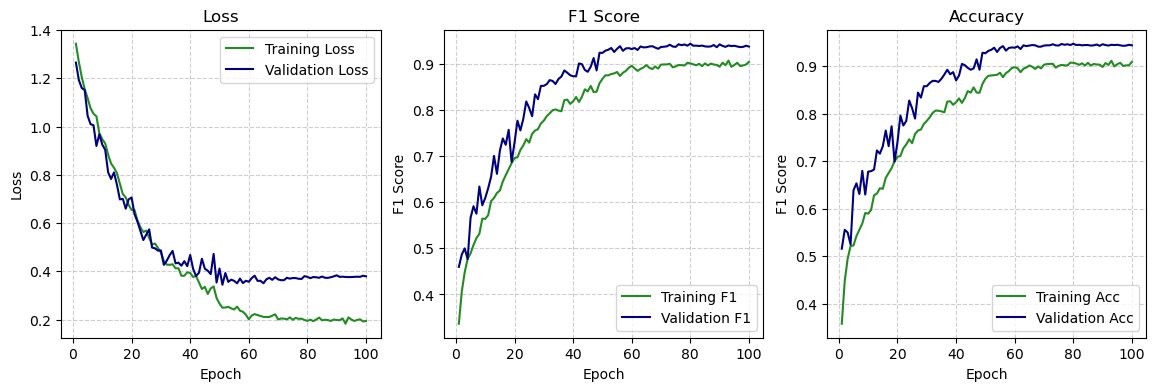

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_best_cnn(num_epochs=100, best_params=best_params, trainval_paths = trainval_paths,
               trainval_labels = trainval_labels, num_classes=4, device = device)

##### Fine-tuning of the pre-trained Resnet

In [22]:
# Structure of resnet
resnet = models.resnet50(pretrained=True)
for name, module in resnet.named_children():
    print(name, "→", module.__class__.__name__)

/opt/conda/envs/bigdata/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/bigdata/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


conv1 → Conv2d
bn1 → BatchNorm2d
relu → ReLU
maxpool → MaxPool2d
layer1 → Sequential
layer2 → Sequential
layer3 → Sequential
layer4 → Sequential
avgpool → AdaptiveAvgPool2d
fc → Linear


In [23]:
def get_resnet_classifier(num_classes):
    model = models.resnet50(pretrained=True)

    # Freeze the convolutional layers
    for param in model.parameters():
        param.requires_grad = False

    # Change the last layers
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    def extract_features(x): 
        # Recreate everuthiny except the last layer
        x = model.conv1(x) 
        x = model.bn1(x) 
        x = model.relu(x) 
        x = model.maxpool(x) 
        x = model.layer1(x) 
        x = model.layer2(x) 
        x = model.layer3(x) 
        x = model.layer4(x) 
        x = model.avgpool(x) # shape: (batch, 2048, 1, 1) 
        x = torch.flatten(x, 1) # shape: (batch, 2048) 
        return x

    model.extract_features = extract_features
    
    return model

# only the last layer is trained

In [37]:
def train_resnet_classifier(model, best_params, trainval_paths, trainval_labels, num_epochs, device="cuda"):

    train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=0.2, random_state=41, stratify=trainval_labels
    )

    # Compute class weights from training labels only
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum()  # normalize

    class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
    print("Class weights:", class_weights)

    train_dataset = BOLD5000Dataset(train_paths, train_labels, transform = transform_resnet)
    val_dataset = BOLD5000Dataset(val_paths, val_labels, transform = transform_resnet)

    train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False, pin_memory=True)
        
    # Criterion, optimizer and scheduler
    criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))

    if best_params['optimizer'] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
    elif best_params['optimizer'] == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=best_params['lr'], momentum=0.9)
        
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s = [], [], [], [], [], []

    # For restoring best weights
    best_val_f1 = 0.0
    best_model_state = None
    best_epoch = 0
    
    model = model.to(device)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_preds, train_true = [], []
        train_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
     
            train_preds.extend(preds.cpu().numpy())
            train_true.extend(labels.cpu().numpy())

        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_true, train_preds)
        train_f1 = f1_score(train_true, train_preds, average="macro", zero_division=0)

        train_accs.append(train_acc)
        train_losses.append(train_loss)
        train_f1s.append(train_f1)


        # Validation
        model.eval()
        val_loss = 0
        val_preds, val_true = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = outputs.max(1)
    

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_true, val_preds)
        val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)

        val_accs.append(val_acc)
        val_losses.append(val_loss)
        val_f1s.append(val_f1)

        # Scheduler step
        scheduler.step(val_loss)


        # For restoring best weights
        if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict()
                best_epoch = epoch
  
        # Print metrics
        print(f"Epoch {epoch:3d}/{num_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        

    # At the end of the training, restore the best weights
    if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"Restored best model with F1 = {best_val_f1:.4f} at epoch {best_epoch}")

    torch.save(model.state_dict(), "/workspace/devcontainer-bigdata/models/best_model_resnet.pt")

    print('\n')

    if True:
        # Plots
        fig, axes = plt.subplots(1,3, figsize=(14,4))
        axes = axes.flatten()
        # Losses
        axes[0].plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', color='forestgreen')
        axes[0].plot(range(1, len(train_losses)+1), val_losses, label='Validation Loss', color='navy')
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # F1 scores
        axes[1].plot(range(1, len(train_f1s)+1), train_f1s, label='Training F1', color='forestgreen')
        axes[1].plot(range(1, len(val_f1s)+1), val_f1s, label='Validation F1', color='navy')
        axes[1].set_title("F1 Score")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1 Score")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Accuracies
        axes[2].plot(range(1, len(train_accs)+1), train_accs, label='Training Acc', color='forestgreen')
        axes[2].plot(range(1, len(val_accs)+1), val_accs, label='Validation Acc', color='navy')
        axes[2].set_title("Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("F1 Score")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.6)     

    return model

/opt/conda/envs/bigdata/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/bigdata/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Class weights: [0.19634883 0.23564395 0.44351456 0.12449266]
Epoch   0/40        Train Loss:    0.6632  -  Train Acc:  0.787  -  Train F1:  0.750             Val Loss:    0.4869  -  Val Acc:  0.860  -  Val F1:  0.835
Epoch   1/40        Train Loss:    0.4353  -  Train Acc:  0.860  -  Train F1:  0.839             Val Loss:    0.4543  -  Val Acc:  0.817  -  Val F1:  0.795
Epoch   2/40        Train Loss:    0.4126  -  Train Acc:  0.859  -  Train F1:  0.838             Val Loss:    0.4106  -  Val Acc:  0.837  -  Val F1:  0.814
Epoch   3/40        Train Loss:    0.3580  -  Train Acc:  0.878  -  Train F1:  0.861             Val Loss:    0.3792  -  Val Acc:  0.862  -  Val F1:  0.838
Epoch   4/40        Train Loss:    0.3375  -  Train Acc:  0.881  -  Train F1:  0.866             Val Loss:    0.3904  -  Val Acc:  0.839  -  Val F1:  0.820
Epoch   5/40        Train Loss:    0.3386  -  Train Acc:  0.879  -  Train F1:  0.861             Val Loss:    0.3817  -  Val Acc:  0.858  -  Val F1:  0.831
Epo

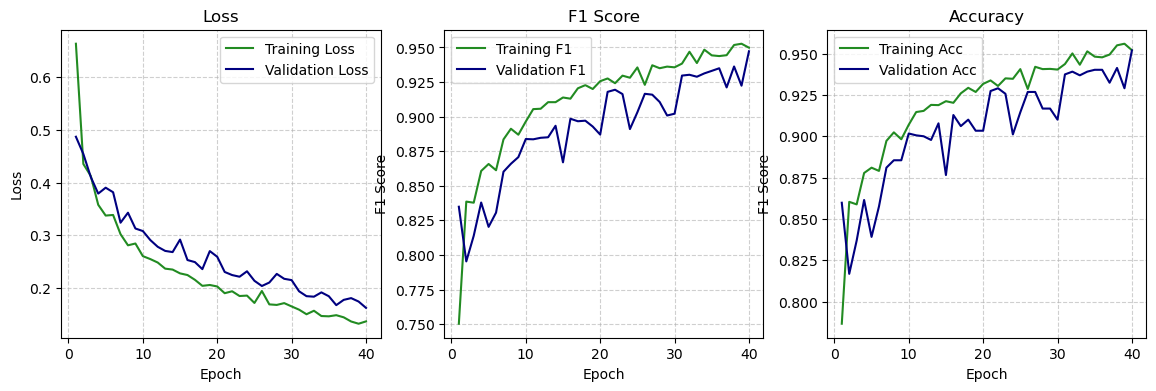

In [40]:
resnet_model = get_resnet_classifier(num_classes=4)
resnet_trained_model = train_resnet_classifier(resnet_model, best_params, trainval_paths=trainval_paths, trainval_labels=trainval_labels, num_epochs=40, device="cuda")

#### Test both models on the same test set

In [8]:
# Dataset for CNN
test_dataset_cnn = BOLD5000Dataset(test_paths, test_labels, transform=transform_cnn)

# Dataset for ResNet
test_dataset_resnet = BOLD5000Dataset(test_paths, test_labels, transform=transform_resnet)

test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [19]:
def evaluate_model(model, dataloader, device="cuda"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            pred = outputs.argmax(dim=1)

            preds.append(pred.cpu())
            trues.append(labels.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro", zero_division=0)

    return acc, f1

In [20]:
best_cnn_model = SimpleCNN(num_classes=4, num_filters=best_params['num_filters'])
best_cnn_model.load_state_dict(torch.load("/workspace/devcontainer-bigdata/models/best_model_cnn.pt"))
best_cnn_model = best_cnn_model.to("cuda")

cnn_acc, cnn_f1 = evaluate_model(best_cnn_model, test_loader_cnn)
print(f"CNN Test Accuracy: {cnn_acc:.3f}")
print(f"CNN Test F1:       {cnn_f1:.3f}")

/tmp/ipykernel_837/1640963391.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_cnn_model.load_state_dict(torch.load("/workspace/devcontainer-bigdata/models/best_mode

CNN Test Accuracy: 0.954
CNN Test F1:       0.948


In [44]:
num_classes = 4
best_resnet_model = get_resnet_classifier(num_classes)
best_resnet_model.load_state_dict(torch.load( "/workspace/devcontainer-bigdata/models/best_model_resnet.pt", map_location=device ))
best_resnet_model.to(device)
resnet_acc, resnet_f1 = evaluate_model(best_resnet_model, test_loader_resnet)
print(f"ResNet Test Accuracy: {resnet_acc:.3f}")
print(f"ResNet Test F1:       {resnet_f1:.3f}")

/opt/conda/envs/bigdata/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/bigdata/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_837/1679557380.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untru

ResNet Test Accuracy: 0.950
ResNet Test F1:       0.942


#### Extract the features

##### Comparison between the features extracted with ResNet and simple CNN

In [46]:
best_cnn_model = SimpleCNN(num_classes=4, num_filters=best_params['num_filters'])
best_cnn_model.load_state_dict(torch.load("/workspace/devcontainer-bigdata/models/best_model_cnn.pt"))
best_cnn_model = best_cnn_model.to("cuda")

/tmp/ipykernel_837/11901206.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_cnn_model.load_state_dict(torch.load("/workspace/devcontainer-bigdata/models/best_model_

In [47]:
best_resnet_model.eval()
best_cnn_model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adapt): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=1024, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [48]:
loader_resnet = DataLoader(test_dataset_resnet, batch_size=1, shuffle=True)
loader_cnn    = DataLoader(test_dataset_cnn, batch_size=1, shuffle=True)

imgs_resnet, _ = next(iter(loader_resnet))
imgs_cnn, _    = next(iter(loader_cnn))

imgs_resnet = imgs_resnet.to("cuda")
imgs_cnn    = imgs_cnn.to("cuda")

In [49]:
with torch.no_grad():
    feats_resnet = best_resnet_model.extract_features(imgs_resnet)   # (5, 2048)
    feats_cnn    = best_cnn_model.extract_features(imgs_cnn)         # (5, 32)

print("ResNet features shape:", feats_resnet.shape)
print("CNN features shape:", feats_cnn.shape)

ResNet features shape: torch.Size([1, 2048])
CNN features shape: torch.Size([1, 32])


Since the pre-trained ResNet has been trained on much more images, and learned more features (edges, texture, shapes, patterns), while the small CNN has only seen my dataset, I chose to use ResNet as feature extractor. In this way, the features are better and there will not be the contribution of "bad features" in the final classification task (the core project, fMRI data --> labels)

And also, the features extracted from Resnet have a higher dimension, so we can expect them to be more informative.

Last reason, the choice of using ResNet is also to mantain more faithfulness with the paper that inspired this project. 

##### Extract features with ResNet

In [ ]:
# Function to extract features from a single image
import torch
from PIL import Image
import torchvision.transforms as T

transform_resnet = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def extract_features_resnet(image_path, model, device="cpu"):
    """
    Loads and image, applies transform and returns features
    """
    model.eval()

    # Loads the image
    img = Image.open(image_path).convert("RGB")

    # Applies transform
    x = transform_resnet(img).unsqueeze(0).to(device)

    # Extract features (2048-D)
    with torch.no_grad():
        feats = model.extract_features(x)   # shape (1, 2048)

    return feats.cpu().numpy().flatten()    # shape (2048,)

# Res Net 's last convolutional block has 2048 feature maps (channels)
# so it returns a vector of 2048 ,which is then given to the classifier

In [51]:
X_features=[]
y=[]
for row in range(len(trials_df)):
    
    # Do NOT consider coco images (there shouldn't be in trials_df)
    assert trials_df['dataset'][row] != 'coco' and trials_df['dataset'][row] != 'COCO'

    dataset_type = trials_df['dataset'][row]
    if 'imagenet' in dataset_type:
        dataset='ImageNet'
    elif 'scene' in dataset_type:
        dataset='Scene'
    else:
        print(f'Error at row {row}')
    image_name = trials_df['image_name'][row]
    image_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli','Presented_Stimuli', dataset, image_name)

    img_features = extract_features_resnet(image_path, best_resnet_model, device=device)

    # Add features and labels
    X_features.append(img_features)
    y.append(trials_df['label'][row])

X_features = np.array(X_features)
print("Shape feature matrix:", X_features.shape)

Shape feature matrix: (11193, 2048)


In [52]:
# Save
np.savez(os.path.join(variables.BOLD5000_PATH,"image_features_resnet.npz"), features=X_features, labels=y)

# Load
if False:
    data = np.load("image_features_resnet.npz")
    print(data["features"].shape, len(data["labels"]))